## Libraries

In [2]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler



## Preliminary Analysis

In this section, basic operations are performed: loading the data and running simple commands to understand its structure.

In [5]:
df = pd.read_csv('titanic_sub_2.csv')
df.head(6)

,PassengerId,Sex,Age,Pclass,Embarked,Survived
0,1,male,22.0,3,S,0
1,2,female,38.0,1,C,1
2,3,female,26.0,3,S,1
3,4,female,35.0,1,S,1
4,5,male,35.0,3,S,0
5,6,male,NaN,3,Q,0


In [6]:
df.describe()

,PassengerId,Age,Pclass,Survived
count,891.000000,714.000000,891.000000,891.000000
mean,446.000000,29.699118,2.308642,0.383838
std,257.353842,14.526497,0.836071,0.486592
min,1.000000,0.420000,1.000000,0.000000
25%,223.500000,20.125000,2.000000,0.000000
50%,446.000000,28.000000,3.000000,0.000000
75%,668.500000,38.000000,3.000000,1.000000
max,891.000000,80.000000,3.000000,1.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Sex          891 non-null    object 
 2   Age          714 non-null    float64
 3   Pclass       891 non-null    int64  
 4   Embarked     889 non-null    object 
 5   Survived     891 non-null    int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 41.9+ KB


There are fields with missing values that will need to be addressed, and categorical variables that will require encoding before training the model.

### Histograms
In this phase, the data is manipulated to prepare it for Canva charts. The most important change is the transformation of the "Age" column to create age groups.
To preserve the integrity of the original dataframe, these operations are performed on df_titanic, which is a copy of df (the original dataframe).

In the following sections, the original dataframe is used again.

In [10]:
# create a copy to perform operations on the Age column
df_titanic= df.copy()

print("--- 1. DATA FOR GENDER CHART (bar chart) ---")
gender_data = df_titanic.groupby('Sex')['Survived'].value_counts(normalize=True).unstack() * 100
print(gender_data)
print("\n")

print("--- 2. DATA FOR CLASS CHART (100% Stacked Bar) ---")
class_data = pd.crosstab(df_titanic['Pclass'], df_titanic['Survived'], normalize='index') * 100
print(class_data)
print("\n")

print("--- 3. DATA FOR AGE GROUPS (horizontal bar chart) ---")
# Create age groups to make the chart readable in Canva
bins = [0, 12, 18, 35, 60, 100]
labels = ['Children (0-12)', 'Teenagers (13-18)', 'Adults (19-35)', 'Senior Adults (36-60)', 'Elderly (60+)']
df_titanic['AgeGroup'] = pd.cut(df_titanic['Age'], bins=bins, labels=labels)
age_data = pd.crosstab(df_titanic['AgeGroup'], df_titanic['Survived'], normalize='index') * 100
print(age_data)

--- 1. DATA FOR GENDER CHART (bar chart) ---
Survived          0          1
Sex                           
female    25.796178  74.203822
male      81.109185  18.890815


--- 2. DATA FOR CLASS CHART (100% Stacked Bar) ---
Survived          0          1
Pclass                        
1         37.037037  62.962963
2         52.717391  47.282609
3         75.763747  24.236253


--- 3. DATA FOR AGE GROUPS (horizontal bar chart) ---
Survived                       0          1
AgeGroup                                   
Children (0-12)        42.028986  57.971014
Teenagers (13-18)      57.142857  42.857143
Adults (19-35)         61.731844  38.268156
Senior Adults (36-60)  60.000000  40.000000
Elderly (60+)          77.272727  22.727273


Survived 0: percentage of deceased, Survived 1: percentage of survivors

## Dataset Preparation for the Model

From this point on, df is used again — the original dataframe that has not been modified in any way by the operations in the previous section.

In this section, the target variable — the one the model aims to predict — is separated from the other features. Missing values are handled by filling gaps with the median for numerical variables and the mode for categorical ones.
Afterwards, the categorical variables Sex and Embarked are encoded to make the dataframe ready for model training.

### Train, Validation and Test Set Split

The dataset is first split in a 75:25 ratio into a Training Set and a Test Set respectively. The latter will be used for the final evaluation of the model. The 75% making up the Training Set is then split again using the same ratio, producing another Training Set and another Test Set, referred to as the Validation Set. These last two sets are the ones used for training the model.

In [16]:
# Separate Target and Features (without transformations)
y = df['Survived']
X = df.drop(columns=['Survived', 'PassengerId'])

# First split: 75% Temp Train, 25% Test
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# Second split: Training and Validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.25, random_state=0
)

### Pipeline Definition
The Pipeline ensures that imputation and encoding are computed correctly every time .fit() is called.
For numerical data, the median is used for imputation, while for categorical data the mode is combined with OneHotEncoding. The latter transforms a text column into multiple numerical columns of 0s and 1s. The drop='first' parameter removes the first column to avoid redundant information (dummy variable trap). For example, in a column like Sex with two possible values, the encoder would create two columns: Sex_Male and Sex_Female. But these would be redundant: knowing that a passenger is not male (0) automatically tells us they are female (1).

In [18]:
# Define column subgroups
num_features = ['Age', 'Pclass']
cat_features = ['Sex', 'Embarked']

# Preprocessing for numerical data: Median imputation
num_transformer = SimpleImputer(strategy='median')

# Preprocessing for categorical data: Mode imputation + OneHotEncoding
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combine both streams into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

print("Preprocessing pipeline defined.")

Preprocessing pipeline defined.


## Depth Validation

In this phase, the tree depth is tested. The Pipeline ensures that the SimpleImputer learns the median only from X_train.
For each depth, the accuracy is computed, and the resulting values are then compared. The winner will be the tree with the highest accuracy.

In [20]:
depths = [2, 3, 4, 5, 10, 25, None]
best_acc = 0
best_depth = None

for d in depths:
    # Full pipeline: Preprocessing + Model
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=d, random_state=0))
    ])

    # fit computes medians/modes only on X_train
    model_pipeline.fit(X_train, y_train)

    # Predict on validation set
    val_preds = model_pipeline.predict(X_val)
    acc = accuracy_score(y_val, val_preds)

    print(f"Depth {d if d else 'Max'}: Accuracy = {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_depth = d

print(f"\nBest depth: {best_depth}")

Depth 2: Accuracy = 0.7904
Depth 3: Accuracy = 0.8204
Depth 4: Accuracy = 0.8204
Depth 5: Accuracy = 0.8024
Depth 10: Accuracy = 0.7844
Depth 25: Accuracy = 0.7784
Depth Max: Accuracy = 0.7784

Best depth: 3


The best depths are 3 and 4, tied. This means that for greater depths the model starts overfitting.
For the next phase, depth 3 is chosen, because given equal accuracy, a model that achieves the result with less complexity is preferable.

## Final Training on the Test Set
Once the best_depth is obtained, the model is retrained on X_train_temp (Train + Validation).
The Pipeline recomputes the statistics on this larger set and applies them to the test set.

In [23]:
# Final pipeline with best depth
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=best_depth, random_state=0))
])

# Train on Train + Validation
final_pipeline.fit(X_train_temp, y_train_temp)

# Final test
test_preds = final_pipeline.predict(X_test)
final_acc = accuracy_score(y_test, test_preds)

print(f"Final accuracy on the Test Set: {final_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, test_preds, target_names=['Not Survived', 'Survived']))

Final accuracy on the Test Set: 0.8117

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.79      0.94      0.86       139
    Survived       0.86      0.60      0.70        84

    accuracy                           0.81       223
   macro avg       0.83      0.77      0.78       223
weighted avg       0.82      0.81      0.80       223



The accuracy obtained is consistent with that of the Validation Set.

### Baseline Comparison
To contextualize the performance of the Decision Tree, two baselines were implemented using Logistic Regression and KNN. This comparison verifies whether the greater complexity of the Decision Tree is justified by a significant improvement in accuracy over simpler models.

In this case, the models are trained directly on X_train_temp, since neither of the two baseline models has hyperparameters to validate. For the Decision Tree, instead, a validation set was used to find the optimal depth.

#### Logistic Regression

In [27]:
# 1. Define a specific preprocessor for Logistic Regression that includes Scaling
# Note: cat_transformer is the same as before, only num_transformer changes
num_transformer_scaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())  # Essential for linear models
])

preprocessor_baseline = ColumnTransformer(
    transformers=[
        ('num', num_transformer_scaled, num_features),
        ('cat', cat_transformer, cat_features)
    ])

# 2. Logistic Regression pipeline
LR_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_baseline),
    ('classifier', LogisticRegression(random_state=0))
])

# 3. Train on Train + Validation set
LR_pipeline.fit(X_train_temp, y_train_temp)

# 4. Evaluate on Test Set
LR_preds = LR_pipeline.predict(X_test)
LR_acc = accuracy_score(y_test, LR_preds)

print(f"Logistic Regression accuracy with Scaling: {LR_acc:.4f}")
print(f"Decision Tree accuracy: {final_acc:.4f}")

# 5. Comparison
differenza = (final_acc - LR_acc) * 100
print(f"\nIl Decision Tree performa meglio della baseline del {differenza:.2f}%")

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, LR_preds, target_names=['Not Survived', 'Survived']))

Logistic Regression accuracy with Scaling: 0.7937
Decision Tree accuracy: 0.8117

Il Decision Tree performa meglio della baseline del 1.79%

Logistic Regression Classification Report:
              precision    recall  f1-score   support

Not Survived       0.84      0.83      0.83       139
    Survived       0.72      0.74      0.73        84

    accuracy                           0.79       223
   macro avg       0.78      0.78      0.78       223
weighted avg       0.79      0.79      0.79       223



#### KNN

In [29]:
# KNN pipeline
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_baseline), # Use the one with StandardScaler!
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# Training and Test
knn_pipeline.fit(X_train_temp, y_train_temp)
knn_preds = knn_pipeline.predict(X_test)
knn_acc = accuracy_score(y_test, knn_preds)

print(f"KNN accuracy: {knn_acc:.4f}")
print(f"Decision Tree accuracy: {final_acc:.4f}")

# 5. Comparison
differenza = (final_acc - knn_acc) * 100
print(f"\nIl Decision Tree performa meglio della baseline knn del {differenza:.2f}%")

print("\nKNN Model Classification Report:")
print(classification_report(y_test, knn_preds, target_names=['Not Survived', 'Survived']))

print(f"\nSUMMARY\n LR_accuracy = {LR_acc:.4f}\n KNN_accuracy = {knn_acc:.4f}\n DecisionTree_accuracy = {final_acc:.4f}")

KNN accuracy: 0.8027
Decision Tree accuracy: 0.8117

Il Decision Tree performa meglio della baseline knn del 0.90%

KNN Model Classification Report:
              precision    recall  f1-score   support

Not Survived       0.81      0.89      0.85       139
    Survived       0.79      0.65      0.71        84

    accuracy                           0.80       223
   macro avg       0.80      0.77      0.78       223
weighted avg       0.80      0.80      0.80       223


SUMMARY
 LR_accuracy = 0.7937
 KNN_accuracy = 0.8027
 DecisionTree_accuracy = 0.8117


Although the Decision Tree outperforms Logistic Regression and KNN in terms of accuracy, a deeper analysis via the Confusion Matrix and Classification Report (see the dedicated section) reveals how the model handles class imbalance.

## Charts for Understanding the Model
In this section, three charts are produced and analyzed to better understand the model that was built.

### Decision Tree
First, the names of the transformed columns must be extracted to display them on the tree nodes.

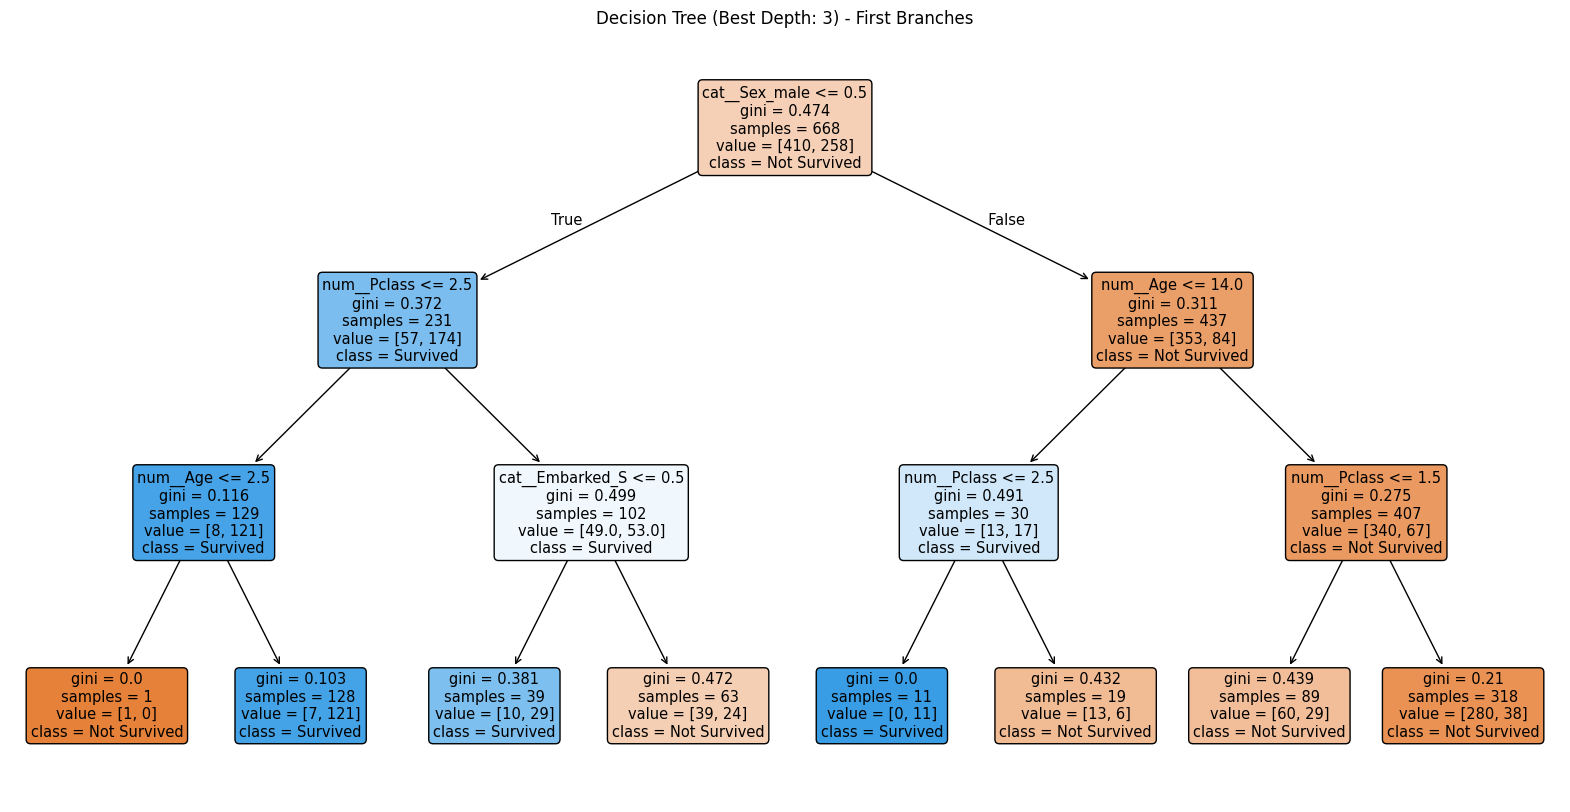

In [33]:


# 1. Retrieve column names and model
feature_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()
tree_model = final_pipeline.named_steps['classifier']

# 2. Plot the Tree (limited to depth 3 for readability)
plt.figure(figsize=(20,10)) # Large figure for readability
plot_tree(tree_model,
          feature_names=feature_names,
          class_names=['Not Survived', 'Survived'],
          filled=True,
          rounded=True,
          max_depth=3)

plt.title(f"Decision Tree (Best Depth: {best_depth}) - First Branches")
plt.show()

Colors: the bluer the node, the more likely that passengers in that group survived. The more orange, the more likely they did not.

Gini (or Entropy): this is the impurity index. The closer it is to 0, the purer the node (meaning it contains almost exclusively survivors or almost exclusively deceased passengers).

### Feature Analysis

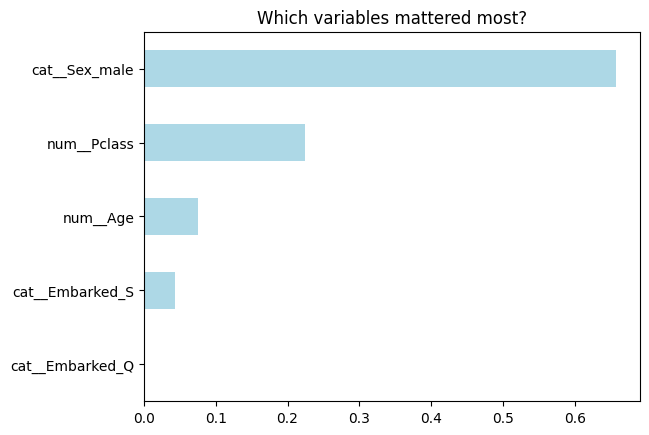

In [36]:
# Feature importances

importances = pd.Series(tree_model.feature_importances_, index=feature_names)
importances.sort_values().plot(kind='barh', color='lightblue')
plt.title("Which variables mattered most?")
plt.show()

The Feature Importance value (technically known as Gini Importance or Mean Decrease Impurity) indicates how much each variable contributed to reducing disorder (the Gini index) within the tree.

High value: The variable was used frequently and/or at high nodes in the tree (those that split large groups of passengers); it is a determining variable.

Value close to zero: The variable was used rarely, only in very deep branches for minor corrections, or was not used at all.

Embarked_Q and Embarked_S have very low importance. The boarding port is often correlated with class (Pclass), and the tree prefers to use class directly as it is a stronger predictor of wealth (and therefore likelihood of survival).

### Confusion Matrix

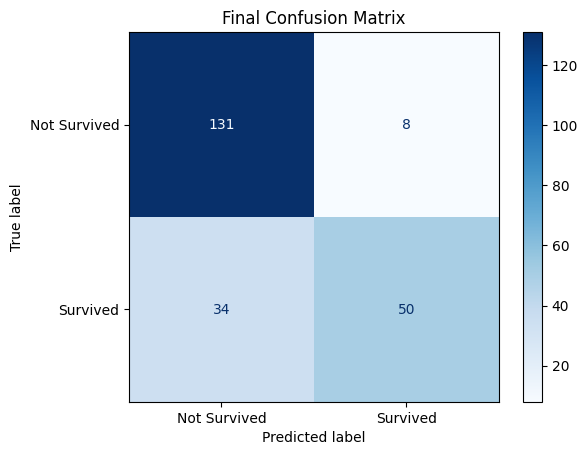


Classification Report:
              precision    recall  f1-score   support

Not Survived       0.79      0.94      0.86       139
    Survived       0.86      0.60      0.70        84

    accuracy                           0.81       223
   macro avg       0.83      0.77      0.78       223
weighted avg       0.82      0.81      0.80       223



In [39]:
# Generate the matrix
cm = confusion_matrix(y_test, test_preds)
# Display it graphically
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived']).plot(cmap='Blues')
plt.title("Final Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, test_preds, target_names=['Not Survived', 'Survived']))

The matrix divides predictions into four main categories:

- True Negatives: 131
The model correctly predicted that 131 passengers did not survive. This is the strongest class.

- True Positives: 50
The model correctly predicted that 50 passengers survived.

- False Negatives: 34 (Type II Error)
The model predicted that 34 passengers would not survive, but they actually did.

- False Positives: 8 (Type I Error)
The model predicted that 8 passengers would survive, but they actually did not.

Although the overall accuracy is 81%, the Classification Report reveals that this figure is partly driven by the strong performance on the majority class (Non-Survivors, recall 94%).

However, the key strength of the Decision Tree over the baselines (Logistic Regression and KNN) lies in its Precision on the 'Survived' class (86%). This indicates that while the model is conservative in identifying survivors (recall 60%), it generates very few false positives. Among the models compared, the Decision Tree proved the most reliable at limiting overestimation of survival — a qualitative advantage that accuracy alone would not have revealed.